In [1]:
import openmc
import numpy as np
import matplotlib.pyplot as plt

# Example n2: Heterogeneous slab 

Aim: define an heterogeneous material, fill a slab geometry, run a simulation and extract some useful information

# 1. Materials

In [2]:
# Create homogeneous U-water mixture
fuel = openmc.Material(name='Fuel')
fuel.set_density('g/cm3', 4)
fuel.add_element('U', 1, enrichment=1.0) # Add uranium with 5% enrichment
fuel.add_element('O', 4)  
fuel.add_element('H', 4)  
fuel.set_temperature = 800


reflector = openmc.Material(name='Reflector')
reflector.set_density('g/cm3', 1)
reflector.add_nuclide('H1', 2)
reflector.add_nuclide('O16', 1)


# reflector.set_density('g/cm3', 1.7)
# reflector.add_element('C', 1)


# Create materials object
materials = openmc.Materials([fuel, reflector])

materials.export_to_xml()

# 2. Geometry

In [3]:
H = 40
L = 50

# Define slab surfaces
left_fuel =  openmc.XPlane(x0 = -H/2)
right_fuel = openmc.XPlane(x0 = H/2)

left_reflector = openmc.XPlane(x0= -H/2 - L/2, boundary_type = 'vacuum')
right_reflector = openmc.XPlane(x0= H/2 + L/2, boundary_type = 'vacuum')

# Define the regions
fuel_region = +left_fuel & -right_fuel
reflector_left_region = +left_reflector & -left_fuel
reflector_right_region = +right_fuel & -right_reflector

# Define the cells
fuel_cell = openmc.Cell(region=fuel_region, fill = fuel)
reflector_left_cell = openmc.Cell(region=reflector_left_region, fill = reflector)
reflector_right_cell = openmc.Cell(region=reflector_right_region, fill = reflector)


# Create universe and geometry
universe = openmc.Universe(cells=[fuel_cell, reflector_left_cell, reflector_right_cell])
geometry = openmc.Geometry(universe)

geometry.export_to_xml()

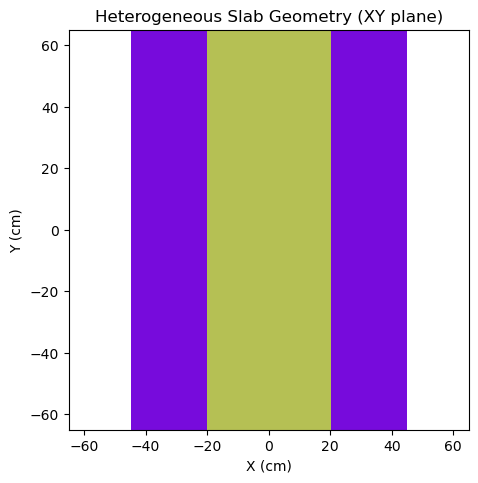

In [4]:
# Create the plot
fig = geometry.plot(basis='xy', origin=(0, 0, 0), width=(2*(H+L/2), 2*(H+L/2)), pixels=(400, 400), color_by='material')

# Set custom x and y labels
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title('Heterogeneous Slab Geometry (XY plane)')
plt.show()

# 3. Settings

In [5]:
settings = openmc.Settings()
settings.run_mode = 'eigenvalue'
settings.batches = 100
settings.inactive = 10
settings.particles = 1000

settings.export_to_xml()

# 4. Tallies

In [6]:
tallies = openmc.Tallies()

# --- Filters ---

# 2. Energy
energy_bins = np.logspace(-5, 7, num=100)  # 100 bins
energy_filter = openmc.EnergyFilter(energy_bins)

energy_th = np.array([1e-5, 0.625])  
energy_filter_th = openmc.EnergyFilter(energy_th)

energy_fast = np.array([0.625, 1e7])  
energy_filter_fast = openmc.EnergyFilter(energy_fast)

# 3. Space 
mesh = openmc.RegularMesh()
mesh.dimension = [100, 1, 1]             
mesh.lower_left = [-H/2-L/2, -1e32, -1e32]       
mesh.upper_right = [H/2+L/2, 1e32, 1e32] 

#
mesh_filter = openmc.MeshFilter(mesh)

# TALLIES
# --- Tally 1: Energy-dependent Flux ---
flux_tally_E = openmc.Tally(name='Phi(E)')
flux_tally_E.filters = [energy_filter]
flux_tally_E.scores = ['flux']

# --- Tally 2: Space Flux ---
flux_tally_x = openmc.Tally(name='Phi(x)')
flux_tally_x.filters = [mesh_filter]
flux_tally_x.scores = ['flux']

# --- Tally 3: Space thermal flux ---
flux_tally_x_th = openmc.Tally(name='Phi_th(x)')
flux_tally_x_th.filters = [mesh_filter, energy_filter_th]
flux_tally_x_th.scores = ['flux']

# --- Tally 4: Space fast flux ---
flux_tally_x_fast = openmc.Tally(name='Phi_f(x)')
flux_tally_x_fast.filters = [mesh_filter, energy_filter_fast]
flux_tally_x_fast.scores = ['flux']

# --- Register the tallies ---
tallies = openmc.Tallies([flux_tally_E, flux_tally_x, flux_tally_x_th, flux_tally_x_fast])

tallies.export_to_xml()

# 5. Run

In [7]:
# Run the simulation and create statepoint file
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

# Postprocessing

In [8]:
sp = openmc.StatePoint('statepoint.100.h5')

In the statepoint there are all the useful information of the simulation

In [9]:
keff = sp.keff

print(f"k-eff = {keff.nominal_value:.5f} +/- {keff.std_dev:.3e}")

k-eff = 0.86201 +/- 3.035e-03


Also, statepoint stores the tally data

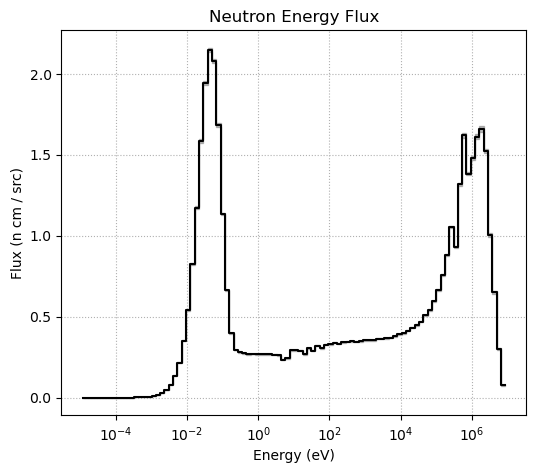

In [10]:
# Energy-dependent flux
flux_tally = sp.get_tally(name='Phi(E)')
flux_vals = flux_tally.mean.flatten()
Uflux_vals = flux_tally.std_dev.flatten()

# Energy bins (midpoints)
energy_mid = 0.5 * (energy_bins[:-1] + energy_bins[1:])

# Plot the flux spectrum
plt.figure(figsize = (6,5))
plt.step(energy_mid, flux_vals, color = "black", where = "pre")
plt.fill_between(energy_mid, flux_vals - Uflux_vals, flux_vals + Uflux_vals, step='pre', color='black', alpha=0.25)
plt.xscale("log")
plt.xlabel("Energy (eV)")
plt.ylabel("Flux (n cm / src)")
plt.title("Neutron Energy Flux")
plt.grid(True, linestyle = ":")
plt.savefig("./phiE_ex2.pdf", format = "pdf", bbox_inches = "tight", dpi = 400)
plt.show()

Space flux

/tmp/ipykernel_3399514/2084954380.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


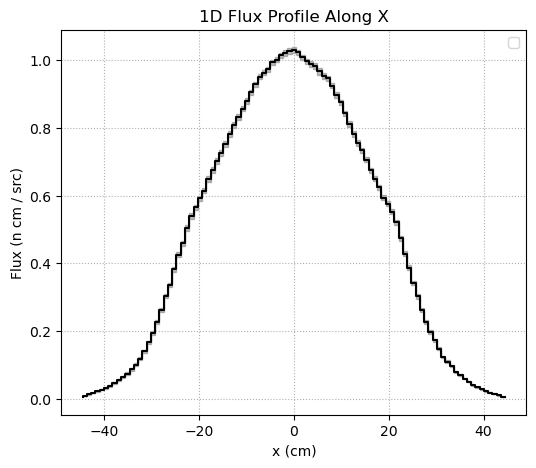

In [11]:
# Space flux
tally = sp.get_tally(name='Phi(x)')
flux_mean = tally.mean.flatten()   # 1D array: [bin0, bin1, ..., binN]
Uflux_mean = tally.std_dev.flatten()

# Access the mesh from the filter
mesh = tally.filters[0].mesh
x_edges = np.linspace(mesh.lower_left[0], mesh.upper_right[0], mesh.dimension[0] + 1)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

plt.figure(figsize = (6,5))
plt.step(x_centers, flux_mean, color = "black", where = "pre")
plt.fill_between(x_centers, flux_mean - Uflux_mean, flux_mean + Uflux_mean, step='pre', color='black', alpha=0.25)
plt.xlabel('x (cm)')
plt.ylabel('Flux (n cm / src)')
plt.title('1D Flux Profile Along X')
plt.grid(True, linestyle = ":")
plt.legend()
plt.savefig("./phiX_tot.pdf", format = "pdf", dpi = 500, bbox_inches = "tight")
plt.show()

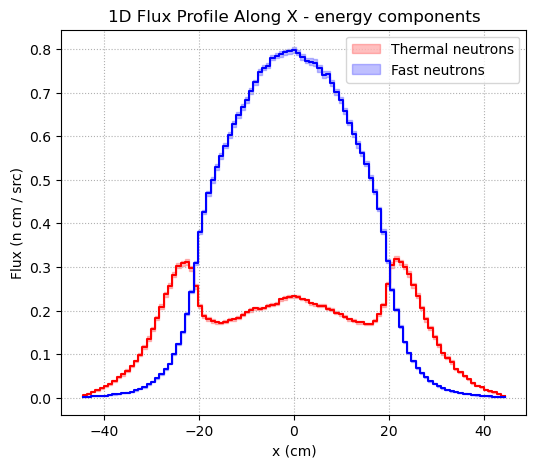

In [12]:
# Space flux - energy components
tally_th = sp.get_tally(name='Phi_th(x)')
flux_mean_th = tally_th.mean.flatten()   # 1D array: [bin0, bin1, ..., binN]
Uflux_mean_th = tally_th.std_dev.flatten()

tally_f = sp.get_tally(name='Phi_f(x)')
flux_mean_f = tally_f.mean.flatten()   # 1D array: [bin0, bin1, ..., binN]
Uflux_mean_f = tally_f.std_dev.flatten()

# Access the mesh from the filter
mesh = tally_th.filters[0].mesh
x_edges = np.linspace(mesh.lower_left[0], mesh.upper_right[0], mesh.dimension[0] + 1)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

plt.figure(figsize = (6,5))
plt.step(x_centers, flux_mean_th, color = "red", where = "pre")
plt.fill_between(x_centers, flux_mean_th - Uflux_mean_th, flux_mean_th + Uflux_mean_th, step='pre', color='red', alpha=0.25, label = "Thermal neutrons")

plt.step(x_centers, flux_mean_f, color = "blue", where = "pre")
plt.fill_between(x_centers, flux_mean_f - Uflux_mean_f, flux_mean_f + Uflux_mean_f, step='pre', color='blue', alpha=0.25, label = "Fast neutrons")

# plt.step(x_centers, flux_mean, color = "black", where = "pre")
# plt.fill_between(x_centers, flux_mean - Uflux_mean, flux_mean + Uflux_mean, step='pre', color='black', alpha=0.25, label = "Total")

#plt.axvline(x=-H/2, ymin = 0, ymax =1.5)

plt.xlabel('x (cm)')
plt.ylabel('Flux (n cm / src)')
plt.title('1D Flux Profile Along X - energy components')
plt.grid(True, linestyle = ":")
plt.legend()
plt.savefig("./phiE_ex2_groups.pdf", format = "pdf", dpi = 500, bbox_inches = "tight")
plt.show()


# Reflector comparison

In [13]:
sp_water = openmc.StatePoint('water_reflected.h5')
sp_graphite = openmc.StatePoint('graphite_reflected.h5')

sp_water.keff, sp_graphite.keff

(0.8620095018151372+/-0.003034764863815303,
 0.9227590265305282+/-0.002882877225112022)

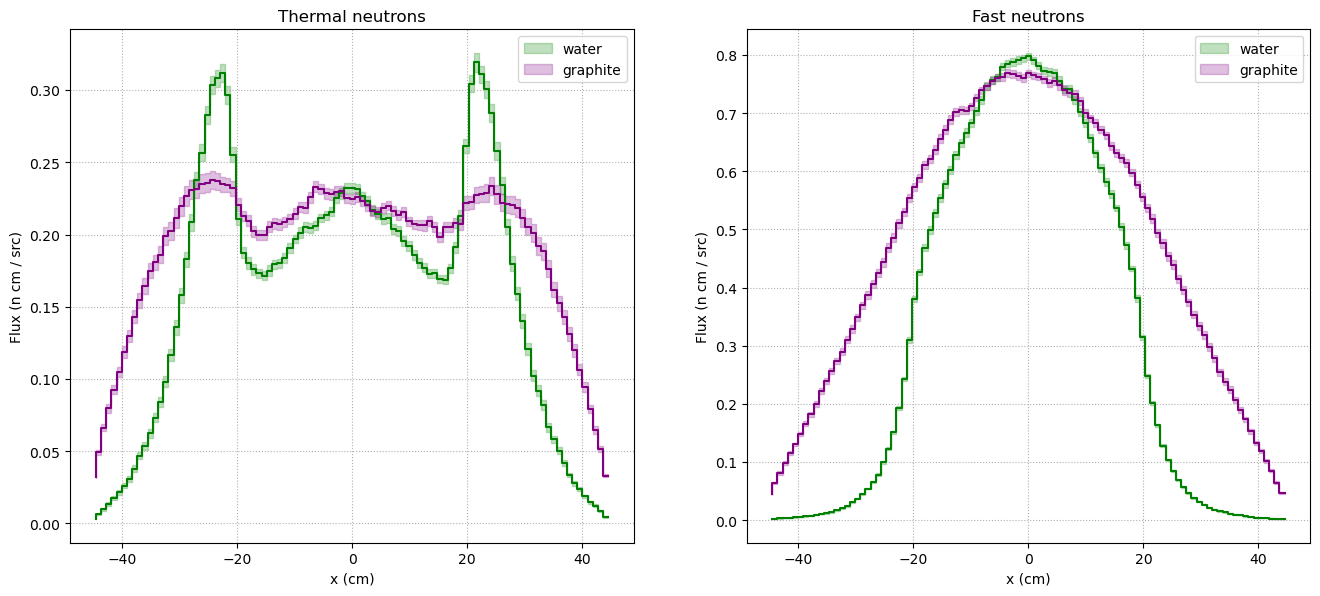

In [14]:
# water
tally_th_water = sp_water.get_tally(name='Phi_th(x)')
flux_mean_th_water = tally_th_water.mean.flatten()   # 1D array: [bin0, bin1, ..., binN]
Uflux_mean_th_water = tally_th_water.std_dev.flatten()

tally_f_water = sp_water.get_tally(name='Phi_f(x)')
flux_mean_f_water = tally_f_water.mean.flatten()   # 1D array: [bin0, bin1, ..., binN]
Uflux_mean_f_water = tally_f_water.std_dev.flatten()

# graphite
tally_th_graphite = sp_graphite.get_tally(name='Phi_th(x)')
flux_mean_th_graphite = tally_th_graphite.mean.flatten()   # 1D array: [bin0, bin1, ..., binN]
Uflux_mean_th_graphite = tally_th_graphite.std_dev.flatten()

tally_f_graphite = sp_graphite.get_tally(name='Phi_f(x)')
flux_mean_f_graphite = tally_f_graphite.mean.flatten()   # 1D array: [bin0, bin1, ..., binN]
Uflux_mean_f_graphite = tally_f_graphite.std_dev.flatten()

# Access the mesh from the filter
mesh = tally_th.filters[0].mesh
x_edges = np.linspace(mesh.lower_left[0], mesh.upper_right[0], mesh.dimension[0] + 1)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

fig, ax = plt.subplots(figsize = (16, 10/1.5), ncols = 2)

ax[0].set_title("Thermal neutrons")
ax[0].step(x_centers, flux_mean_th_water, color = "green", where = "pre")
ax[0].fill_between(x_centers, flux_mean_th_water - Uflux_mean_th_water, flux_mean_th_water + Uflux_mean_th_water, step='pre', color='green', alpha=0.25, label = "water")

ax[0].step(x_centers, flux_mean_th_graphite, color = "purple", where = "pre")
ax[0].fill_between(x_centers, flux_mean_th_graphite - Uflux_mean_th_graphite, flux_mean_th_graphite + Uflux_mean_th_graphite, step='pre', color='purple', alpha=0.25, label = "graphite")

ax[1].set_title("Fast neutrons")
ax[1].step(x_centers, flux_mean_f_water, color = "green", where = "pre")
ax[1].fill_between(x_centers, flux_mean_f_water - Uflux_mean_f_water, flux_mean_f_water + Uflux_mean_f_water, step='pre', color='green', alpha=0.25, label = "water")

ax[1].step(x_centers, flux_mean_f_graphite, color = "purple", where = "pre")
ax[1].fill_between(x_centers, flux_mean_f_graphite - Uflux_mean_f_graphite, flux_mean_f_graphite + Uflux_mean_f_graphite, step='pre', color='purple', alpha=0.25, label = "graphite")

# plt.step(x_centers, flux_mean, color = "black", where = "pre")
# plt.fill_between(x_centers, flux_mean - Uflux_mean, flux_mean + Uflux_mean, step='pre', color='black', alpha=0.25, label = "Total")

#plt.axvline(x=-H/2, ymin = 0, ymax =1.5)

ax[0].set_xlabel('x (cm)')
ax[1].set_xlabel('x (cm)')
ax[0].set_ylabel('Flux (n cm / src)')
ax[1].set_ylabel('Flux (n cm / src)')

ax[0].legend()
ax[1].legend()

ax[0].grid(linestyle = ':')
ax[1].grid(linestyle = ':')
fig.savefig("./phiE_ex2_reflectors.pdf", format = "pdf", dpi = 500, bbox_inches = "tight")
# plt.show()
